# colab_glossa_04 — Дообучение ST-GCN на RTMW-фичах (domain adaptation)

**Зачем этот ноутбук.** Действующая модель (`stgcn_best.pt` / `stgcn_final.pt`,
экспортированная в `gesture_classifier_mobile.onnx` + `stgcn_topk_int8`)
обучалась ИСКЛЮЧИТЕЛЬНО на keypoints, извлечённых через
`controlnet_aux.dwpose.DwposeDetector` (offline-пайплайн, `colab_glossa_00`).
Продакшен (`cv_service`) с недавних пор извлекает keypoints через
`rtmlib` (RTMDet-nano + RTMW) — другую пару моделей с другим detection/pose
bias. Мы уже воспроизвели тот же ПОРЯДОК точек на инференсе
(`_COCO17_TO_TRAINING_ORDER` в `keypoint_extractor.py`), но порядок — не то
же самое, что распределение: сама геометрия/точность/шум RTMW отличается от
DWPose, и модель никогда не видела ни одного такого примера.

**Подход — не полный retrain, а fine-tune (domain adaptation):**
1. Скачать Slovo через `kagglehub` (те же credentials/доступ, что
   `colab_glossa_00`) и сэмплировать несколько клипов на класс из
   `annotations.csv` — **никаких новых записей не требуется**, берём те же
   исходные видео, что уже размечены под сценарий `top200`.
2. Извлечь keypoints из этих клипов ТЕМ ЖЕ кодом, что использует продакшен
   (`rtmlib.Wholebody` + идентичный ремап/нормализация) — так «новый» набор
   отличается от старого именно экстрактором (DWPose → RTMW), а не человеком
   в кадре, это и есть источник разрыва, который мы закрываем.
3. Пересчитать BatchNorm running-статистику модели на новых данных
   (дёшево, без градиентов — часто даёт заметный прирост само по себе).
4. Дообучить с низким LR на смеси {новые RTMW-клипы (с повышенным весом) +
   сэмпл старых DWPose-клипов (для регуляризации, чтобы не забыть остальные
   198 классов, которых в новых данных нет)}.
5. Сравнить accuracy до/после на старой (DWPose) val-выборке — не должно
   заметно просесть — и на новой (RTMW) val-выборке — должно вырасти.
6. Экспортировать в PyTorch/ONNX/**OpenVINO INT8** (квантование — прямо
   здесь, через `nncf.quantize()`, на РЕАЛЬНОЙ калибровочной выборке —
   old val + new RTMW val — а не на синтетическом шуме, которым калибровался
   текущий продакшен-INT8) — всё под НОВЫМИ именами/путями, продакшен-
   артефакты не перезаписываются автоматически, промоушен — руками после
   проверки на камере.

---

> ⚠️ **Если сессия Colab перезапускалась** (Runtime → Restart session) и веса уже сохранены в `finetuned_rtmw/` — **не запускайте ноутбук заново с Ячейки 1.**
> Промотайте вниз до раздела **«🔁 Восстановление после рестарта сессии»** (идёт сразу перед Ячейкой 11b) и начните с него — он подтягивает уже готовые веса и уже извлечённые RTMW-keypoints с Google Drive за секунды, вместо повторного скачивания/дообучения (~2 часа).

## Ячейка 1 — Окружение и пути

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = '/content/drive/MyDrive/glossa'   # поправьте под свою структуру
MODELS_DIR  = f'{DRIVE_ROOT}/models'
DATA_DIR    = f'{DRIVE_ROOT}/data/gestures/processed_64_200'   # существующий DWPose-датасет
OUT_DIR     = f'{DRIVE_ROOT}/data/gestures/rtmw_finetune_out'

import os
os.makedirs(OUT_DIR, exist_ok=True)
print('DATA_DIR (старый DWPose):', DATA_DIR)

Mounted at /content/drive
DATA_DIR (старый DWPose): /content/drive/MyDrive/glossa/data/gestures/processed_64_200


## Ячейка 2 — Установка зависимостей

In [2]:
# nncf и onnx добавлены сюда же (а не установлены позже отдельно) —
# именно поздняя установка nncf после того, как pydot/networkx уже были
# импортированы (через mlflow), требует Restart session. Ставим всё
# одним пакетом ДО первого импорта — тогда рестарт больше не понадобится.
!pip install -q rtmlib onnxruntime openvino nncf onnx torch torchvision scikit-learn mlflow tqdm opencv-python-headless kagglehub

import torch, numpy as np, json, cv2
from pathlib import Path
print('torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.

## Ячейка 3 — Скачивание Slovo + выборка клипов для дообучения

**Не нужно записывать новые видео.** Используем ТЕ ЖЕ исходные клипы Slovo,
что и `colab_glossa_00` (те же Kaggle credentials, тот же `annotations.csv`),
просто извлекаем их через RTMW вместо DWPose — так «новый» набор отражает
реальные жесты датасета, а не самодельные, и разрыв домена закрывается
именно между экстракторами (DWPose vs RTMW), а не между людьми/камерами.

Сэмплируем `CLIPS_PER_CLASS` случайных клипов на каждый из 200 классов
(сценарий `top200`, тот же `class_to_idx.json`, что видит продакшен).

In [3]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

import kagglehub, time
print('Скачиваем датасет Slovo RSL (или берём из кэша, если уже скачан)...')
t0 = time.time()
DATASET_PATH = kagglehub.dataset_download('kapitanov/slovo')
print(f'Готово за {(time.time()-t0)/60:.1f} мин. Путь: {DATASET_PATH}')

import pandas as pd

SLOVO_ROOT = Path(DATASET_PATH)
ANNOT_CSV  = list(SLOVO_ROOT.rglob('annotations.csv'))[0]
df = pd.read_csv(ANNOT_CSV, sep='\t', on_bad_lines='skip')
df = df[df['text'] != 'no_event'].reset_index(drop=True)

class_to_idx = json.loads(Path(f'{DRIVE_ROOT}/data/class_to_idx.json').read_text(encoding='utf-8'))
print(f'{len(class_to_idx)} классов в маппинге (сценарий top200)')

df = df[df['text'].isin(class_to_idx)].reset_index(drop=True)
print(f'Аннотаций после фильтра по 200 классам: {len(df)}')


def find_video(attachment_id: str) -> str | None:
    for split in ['train', 'test', 'val']:
        p = SLOVO_ROOT / 'slovo' / split / f'{attachment_id}.mp4'
        if p.exists():
            return str(p)
    return None


CLIPS_PER_CLASS = 8  # начните с малого — даже 3-5 на класс уже помогает
SEED = 42

sampled = (
    df.groupby('text', group_keys=False)
      .apply(lambda g: g.sample(min(len(g), CLIPS_PER_CLASS), random_state=SEED))
      .reset_index(drop=True)
)
print(f'Выбрано {len(sampled)} клипов ({sampled["text"].nunique()} классов, '
      f'до {CLIPS_PER_CLASS} на класс)')

Скачиваем датасет Slovo RSL (или берём из кэша, если уже скачан)...


  6%|▌         | 858M/14.8G [00:51<14:24, 17.3MB/s]


KeyboardInterrupt: 

## Ячейка 4 — Извлечение keypoints через rtmlib (тот же код, что в продакшене)

Копия логики `services/cv_service/keypoint_extractor.py` — намеренно
скопирована, а не импортирована, чтобы ноутбук был самодостаточным в Colab
(там нет доступа к репозиторию). **Если поменяете
`_COCO17_TO_TRAINING_ORDER` / `_EXTRA_JOINT_SRC` / confidence-порог зануления
в `keypoint_extractor.py` — обновите и здесь**, иначе фичи разъедутся с
продакшеном.

`extract_video_keypoints` принимает `begin`/`end` (кадры), как и
`process_video()` в `colab_glossa_00` — Slovo-видео могут содержать не
только целевой жест, обрезаем строго так же, как офлайн-пайплайн.

In [ ]:
from rtmlib import Wholebody

# ── Идентично keypoint_extractor.py — держать в синхроне ──────────────────── #
_COCO17_TO_TRAINING_ORDER = [0, 6, 8, 10, 5, 7, 9, 12, 14, 16, 11, 13, 15, 2, 1, 4, 3]
_EXTRA_JOINT_SRC = [5, 6, 11, 12, 13, 14, 15, 16, 5, 6]
_LOW_CONF_ZERO_THRESHOLD = 0.3  # см. keypoint_extractor.py::_zero_low_confidence_joints

def remap_coco133_to_75(kp133: np.ndarray) -> np.ndarray:
    body17 = kp133[0:17][_COCO17_TO_TRAINING_ORDER]
    feet6 = kp133[17:23]
    extra10 = body17[_EXTRA_JOINT_SRC]
    pose33 = np.concatenate([body17, feet6, extra10], axis=0)
    left_hand = kp133[91:112]
    right_hand = kp133[112:133]
    kp75 = np.concatenate([pose33, left_hand, right_hand], axis=0).astype(np.float32)
    # зануление низкоуверенных точек — см. Ячейку fix в keypoint_extractor.py
    low_conf = kp75[:, 2] < _LOW_CONF_ZERO_THRESHOLD
    kp75[low_conf] = 0.0
    return kp75


_wholebody = Wholebody(mode='lightweight', backend='onnxruntime', device='cpu', to_openpose=False)

def extract_video_keypoints(video_path: str, begin: int | None = None, end: int | None = None) -> np.ndarray:
    """Возвращает (T_raw, 75, 3) — по одному кадру в диапазоне [begin, end]
    (весь клип, если begin/end не заданы), как process_video() в colab_glossa_00."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    b = max(0, begin) if begin is not None else 0
    e = min(total - 1, end) if end is not None else total - 1

    frames_kp = []
    for idx in range(b, e + 1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frames_kp.append(np.zeros((75, 3), dtype=np.float32))
            continue
        h, w = frame.shape[:2]
        keypoints, scores = _wholebody(frame)
        if keypoints is None or len(keypoints) == 0:
            frames_kp.append(np.zeros((75, 3), dtype=np.float32))
            continue
        best = int(np.argmax([s.mean() for s in scores])) if len(keypoints) > 1 else 0
        kp = np.asarray(keypoints[best], dtype=np.float32)
        sc = np.asarray(scores[best], dtype=np.float32)
        kp[:, 0] = np.clip(kp[:, 0] / w, 0.0, 1.0)
        kp[:, 1] = np.clip(kp[:, 1] / h, 0.0, 1.0)
        kp133 = np.stack([kp[:, 0], kp[:, 1], sc], axis=1)
        frames_kp.append(remap_coco133_to_75(kp133))
    cap.release()
    return np.stack(frames_kp, axis=0) if frames_kp else np.zeros((0, 75, 3), dtype=np.float32)


def normalize_keypoints(kp: np.ndarray) -> np.ndarray:
    """Hip-center + shoulder-scale — идентично colab_glossa_00 / normalizer.py._translate_scale_invariant."""
    HIP_IDX, SHOU_IDX = [11, 12], [5, 6]
    xy = kp[:, :, :2].copy()
    hips_center = np.median(xy[:, HIP_IDX, :], axis=1, keepdims=True)
    xy -= hips_center
    shoulder_dist = np.linalg.norm(xy[:, SHOU_IDX[0], :] - xy[:, SHOU_IDX[1], :], axis=1)
    shoulder_dist = np.maximum(shoulder_dist, 1e-6).reshape(-1, 1, 1)
    xy /= shoulder_dist
    out = kp.copy()
    out[:, :, :2] = xy
    return out


def resample_to(window: np.ndarray, target_T: int = 64) -> np.ndarray:
    T = window.shape[0]
    if T == target_T:
        return window
    src_idx = np.linspace(0, T - 1, target_T)
    lo = np.floor(src_idx).astype(int)
    hi = np.minimum(lo + 1, T - 1)
    alpha = (src_idx - lo)[:, None, None]
    return ((1 - alpha) * window[lo] + alpha * window[hi]).astype(np.float32)

print('Функции извлечения готовы.')

## Ячейка 5 — Прогон выбранных клипов через RTMW

In [ ]:
from tqdm.notebook import tqdm

new_X, new_y, new_paths = [], [], []
skipped = []

for row in tqdm(sampled.itertuples(), total=len(sampled), desc='Извлечение RTMW'):
    vpath = find_video(row.attachment_id)
    if vpath is None:
        skipped.append(row.attachment_id)
        continue
    cls_idx = class_to_idx[row.text]
    raw_kp = extract_video_keypoints(vpath, int(row.begin), int(row.end))
    if raw_kp.shape[0] < 8:
        skipped.append(row.attachment_id)
        continue
    normed = normalize_keypoints(raw_kp)
    resampled = resample_to(normed, target_T=64)
    new_X.append(resampled.astype(np.float16))
    new_y.append(cls_idx)
    new_paths.append(vpath)

new_X = np.stack(new_X, axis=0) if new_X else np.zeros((0, 64, 75, 3), dtype=np.float16)
new_y = np.array(new_y, dtype=np.int64)
print(f'Извлечено {len(new_X)} клипов, классов: {len(set(new_y.tolist()))}')
print(f'Пропущено (видео не найдено/слишком короткое): {len(skipped)}')

np.save(f'{OUT_DIR}/new_X_raw.npy', new_X)      # ещё БЕЗ z-score — только hip/shoulder-норм
np.save(f'{OUT_DIR}/new_y.npy', new_y)

## Ячейка 6 — Train/val split нового набора

При малом числе клипов на класс (5-10) — holdout 1-2 клипа на класс для
валидации, остальное в train. Если на класс всего 1 клип — он идёт только
в train (нельзя оценить точность по этому классу, но дообучение всё равно
полезно).

In [ ]:
from collections import defaultdict
import random
random.seed(42)

by_class = defaultdict(list)
for i, cls in enumerate(new_y.tolist()):
    by_class[cls].append(i)

train_idx, val_idx = [], []
for cls, idxs in by_class.items():
    random.shuffle(idxs)
    if len(idxs) >= 3:
        val_idx.extend(idxs[:1])       # 1 клип на класс в val, если их >=3
        train_idx.extend(idxs[1:])
    else:
        train_idx.extend(idxs)          # слишком мало — всё в train

new_X_train, new_y_train = new_X[train_idx], new_y[train_idx]
new_X_val,   new_y_val   = new_X[val_idx],   new_y[val_idx]
print(f'new train={len(new_X_train)}  new val={len(new_X_val)}')

## Ячейка 7 — Архитектура ST-GCN + загрузка текущего чекпоинта и старого (DWPose) датасета

`load_skeleton_graph`/`GraphConv`/`TCN`/`STGCNBlock`/`STGCN` скопированы
**дословно** из `colab_glossa_01a_train_stgcn_64_200.ipynb` — архитектура и
граф должны быть идентичны тому, на чём обучен чекпоинт, иначе
`load_state_dict()` упадёт по shape mismatch. **Если архитектуру поменяли в
`colab_glossa_01a` — обновите и здесь.**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from scipy.sparse.csgraph import connected_components

A_np = None
A_partition_np = None

def load_skeleton_graph():
    """Граф скелета — дословная копия colab_glossa_01a::load_skeleton_graph()."""
    global A_np, A_partition_np

    COCO_EDGES = [
        (0, 1), (0, 2), (1, 3), (2, 4),
        (5, 6), (5, 7), (6, 8), (7, 9),
        (5, 11), (6, 12), (11, 12),
        (11, 13), (13, 15), (15, 17), (17, 19),
        (12, 14), (14, 16), (16, 18), (18, 20),
        (0, 5), (0, 6),
        (5, 7), (7, 9),
        (6, 8), (8, 10),
    ]
    FEET_EDGES = [
        (17, 19), (19, 21),
        (18, 20), (20, 22),
        (17, 18),
    ]
    EXTRA_EDGES = [
        (23, 5), (24, 6),
        (25, 11), (26, 12),
        (27, 13), (28, 14),
        (29, 15), (30, 16),
        (31, 5), (32, 6),
    ]
    HAND_EDGES = [
        (0, 1), (0, 5), (0, 9), (0, 13), (0, 17),
        (1, 2), (2, 3), (3, 4),
        (5, 6), (6, 7), (7, 8),
        (9, 10), (10, 11), (11, 12),
        (13, 14), (14, 15), (15, 16),
        (17, 18), (18, 19), (19, 20),
    ]

    edges = set()
    for i, j in COCO_EDGES:
        if i < 17 and j < 17:
            edges.add((i, j)); edges.add((j, i))
    for i, j in FEET_EDGES:
        if 17 <= i <= 22 and 17 <= j <= 22:
            edges.add((i, j)); edges.add((j, i))
    for i, j in EXTRA_EDGES:
        edges.add((i, j)); edges.add((j, i))
    for i, j in HAND_EDGES:
        edges.add((33 + i, 33 + j)); edges.add((33 + j, 33 + i))
        edges.add((54 + i, 54 + j)); edges.add((54 + j, 54 + i))

    edges.add((7, 33)); edges.add((33, 7))
    edges.add((4, 54)); edges.add((54, 4))
    edges.add((5, 33)); edges.add((33, 5))
    edges.add((6, 54)); edges.add((54, 6))

    face_nodes = [1, 2, 3, 8, 9, 10]
    for node in face_nodes:
        edges.add((node, 0)); edges.add((0, node))

    edges.add((15, 17)); edges.add((17, 15))
    edges.add((16, 18)); edges.add((18, 16))

    V = 75
    A = np.zeros((V, V), dtype=np.float32)
    for i, j in edges:
        A[i, j] = 1.0; A[j, i] = 1.0
    np.fill_diagonal(A, 1.0)

    isolated = np.where((A > 0).sum(axis=1) - 1 == 0)[0]
    for node in isolated:
        if node < 33:
            A[node, 0] = 1.0; A[0, node] = 1.0
        elif node < 54:
            A[node, 33] = 1.0; A[33, node] = 1.0
        else:
            A[node, 54] = 1.0; A[54, node] = 1.0

    n_components, labels = connected_components(A, directed=False)
    if n_components > 1:
        comp_nodes = [np.where(labels == comp)[0] for comp in range(n_components)]
        for i in range(1, n_components):
            a, b = comp_nodes[0][0], comp_nodes[i][0]
            A[a, b] = 1.0; A[b, a] = 1.0

    deg = A.sum(axis=1)
    d_inv_sqrt = np.where(deg > 1e-8, 1.0 / np.sqrt(deg), 0.0)
    A_norm = A * d_inv_sqrt[:, None] * d_inv_sqrt[None, :]

    binary = (A > 0).astype(np.float32)
    np.fill_diagonal(binary, 0)
    dist = np.full(V, np.inf)
    dist[0] = 0
    queue = [0]
    while queue:
        v = queue.pop(0)
        for u in np.where(binary[v] > 0)[0]:
            if dist[u] == np.inf:
                dist[u] = dist[v] + 1
                queue.append(u)

    partition = np.zeros((3, V, V), dtype=np.float32)
    for i in range(V):
        for j in range(V):
            w = A_norm[i, j]
            if w == 0:
                continue
            if i == j:
                partition[0, i, j] = w
            elif dist[j] <= dist[i]:
                partition[1, i, j] = w
            else:
                partition[2, i, j] = w

    A_np = A_norm
    A_partition_np = partition
    print(f'Граф готов: V={V}, E={len(edges)}, компонент связности={n_components}')
    return A_np, A_partition_np

A_np, A_partition_np = load_skeleton_graph()


class GraphConv(nn.Module):
    """ST-GCN graph convolution."""
    def __init__(self, in_ch: int, out_ch: int, mobile: bool = False) -> None:
        super().__init__()
        self.K = 1 if mobile else 3
        self.mobile = mobile
        if mobile:
            self.register_buffer('A', torch.tensor(A_np, dtype=torch.float32).unsqueeze(0))
        else:
            self.register_buffer('A', torch.tensor(A_partition_np, dtype=torch.float32))
            self.M = nn.Parameter(torch.zeros(self.K, A_np.shape[0], A_np.shape[0]))
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, out_ch, kernel_size=1) for _ in range(self.K)])
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = 0
        for k in range(self.K):
            A_eff = self.A[k] if self.mobile else (self.A[k] + self.M[k])
            branch = self.convs[k](x)
            out = out + torch.einsum('bctv,vw->bctw', branch, A_eff)
        return self.bn(out)


class TCN(nn.Module):
    """Temporal Convolution Block."""
    def __init__(self, ch: int, stride: int = 1, kernel: int = 9, dropout: float = 0.5) -> None:
        super().__init__()
        pad = (kernel - 1) // 2
        self.net = nn.Sequential(
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, kernel_size=(kernel, 1), stride=(stride, 1), padding=(pad, 0)),
            nn.BatchNorm2d(ch),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class STGCNBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1, residual: bool = True,
                 mobile: bool = False, tcn_dropout: float = 0.5) -> None:
        super().__init__()
        self.gcn = GraphConv(in_ch, out_ch, mobile=mobile)
        self.tcn = TCN(out_ch, stride=stride, dropout=tcn_dropout)
        self.relu = nn.ReLU(inplace=True)
        self._no_res = not residual
        if residual and (in_ch != out_ch or stride != 1):
            self.skip = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=(stride, 1)), nn.BatchNorm2d(out_ch))
        elif residual:
            self.skip = nn.Identity()
        else:
            self.skip = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        res = 0 if self._no_res else self.skip(x)
        return self.relu(self.tcn(self.gcn(x)) + res)


class STGCN(nn.Module):
    """ST-GCN для распознавания жестов РЖЯ (датасет Slovo, топ-200 классов)."""
    _CFG = [
        (3, 64, 1, False),
        (64, 64, 1, True),
        (64, 64, 1, True),
        (64, 128, 2, True),
        (128, 128, 1, True),
        (128, 256, 2, True),
        (256, 256, 1, True),
    ]

    def __init__(self, num_classes: int = 200, num_nodes: int = 75, mobile: bool = False,
                 tcn_dropout: float = 0.5, fc_dropout: float = 0.5) -> None:
        super().__init__()
        self.data_bn = nn.BatchNorm1d(3 * num_nodes)
        self.layers = nn.ModuleList([
            STGCNBlock(ic, oc, st, res, mobile=mobile, tcn_dropout=tcn_dropout)
            for ic, oc, st, res in self._CFG
        ])
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.drop = nn.Dropout(fc_dropout)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, V, C = x.shape
        x = x.permute(0, 1, 3, 2).contiguous().view(B * T, C * V)
        x = self.data_bn(x)
        x = x.view(B, T, C, V).permute(0, 2, 1, 3).contiguous()
        for layer in self.layers:
            x = layer(x)
        x = self.pool(x).view(B, -1)
        return self.fc(self.drop(x))

print('Классы ST-GCN определены (идентично colab_glossa_01a).')


CKPT_PATH = f'{MODELS_DIR}/stgcn_final.pt'
NUM_CLASSES, NUM_NODES, SEQ_LEN = 200, 75, 64

model = STGCN(num_classes=NUM_CLASSES, num_nodes=NUM_NODES, mobile=False).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print(f'Загружен чекпоинт: {CKPT_PATH}')

# Старый (DWPose) датасет — для регуляризации при дообучении + контроль регрессии
X_train_old = np.load(f'{DATA_DIR}/train/features.npy', mmap_mode='r')
y_train_old = np.load(f'{DATA_DIR}/train/labels.npy')
X_val_old   = np.load(f'{DATA_DIR}/val/features.npy')
y_val_old   = np.load(f'{DATA_DIR}/val/labels.npy')

norm_stats = np.load(f'{MODELS_DIR}/norm_stats.npz')
mean, std = norm_stats['mean'], norm_stats['std']
std = np.where(std < 1e-6, 1.0, std)
print(f'Старый train={len(X_train_old)}  Старый val={len(X_val_old)}')

## Ячейка 8 — Recalibration BatchNorm (шаг 0, до полноценного fine-tune)

`STGCN.data_bn` — это `nn.BatchNorm1d`, чья running-статистика (mean/var)
"заморожена" под распределение DWPose-фичей. Простой и очень дешёвый первый
шаг domain adaptation: прогнать новые RTMW-клипы через модель в
`model.train()` режиме **без backprop** — только обновить running-статистику
BatchNorm. Иногда сам по себе даёт заметный прирост, до всякого fine-tune
градиентами. Пропустите эту ячейку, если новых клипов совсем мало (< 20-30) —
на таком объёме recalibration может, наоборот, ухудшить статистику.

**Важно:** `colab_glossa_01a` обрезает выбросы (`np.clip(x, -10, 10)`) на
"сырых" (hip/shoulder-normalized, ещё не z-scored) координатах ПЕРЕД
подсчётом статистики нормализации — это единственный, но критичный шаг,
которого не было в первой версии этого ноутбука: RTMW иногда даёт единичные
выбросы (плохо детектированный кадр → shoulder_dist около нуля → взрыв
координат после деления), и без обрезки такие значения долетают до z-score
±100+ и разносят running-статистику BatchNorm в NaN на самом
recalibration-шаге. `to_zscore()` ниже воспроизводит точно тот же порядок
операций (clip → mean/std), что и в трейне.

In [ ]:
CLIP_VAL = 10.0  # идентично colab_glossa_01a::clip_init

def to_zscore(x_raw: np.ndarray) -> np.ndarray:
    """Обрезка выбросов + z-score — тот же порядок, что colab_glossa_01a
    (clip на сырых hip/shoulder-normalized координатах, ПОТОМ (x-mean)/std)."""
    x_clipped = np.clip(x_raw.astype(np.float32), -CLIP_VAL, CLIP_VAL)
    return ((x_clipped - mean[0]) / std[0]).astype(np.float32)


if len(new_X_train) >= 20:
    new_X_train_z = to_zscore(new_X_train)
    recalib_tensor = torch.tensor(new_X_train_z, dtype=torch.float32)

    model.train()
    with torch.no_grad():
        for i in range(0, len(recalib_tensor), 16):
            model(recalib_tensor[i:i+16].to(DEVICE))
    model.eval()
    print(f'BatchNorm recalibrated на {len(recalib_tensor)} новых сэмплах.')
else:
    print(f'Пропущено — только {len(new_X_train)} новых train-сэмплов (< 20), риск ухудшить статистику.')

## Ячейка 9 — Fine-tune с низким LR на смеси старых + новых данных

- LR на 1-2 порядка ниже, чем при исходном обучении (`CFG['lr']=1e-3` →
  здесь `1e-4` или ниже) — чтобы не "перезаписать" то, что модель уже
  выучила на 200 классах, а лишь подстроить под новое распределение.
- Новые RTMW-клипы **умышленно oversampled** (повторены N раз в эпохе) —
  иначе на фоне тысяч старых DWPose-примеров их градиентный вклад
  теряется.
- Малое число эпох (`FT_EPOCHS`) — это fine-tune, не обучение с нуля.

In [ ]:
FT_LR = 1e-4
FT_EPOCHS = 15
FT_BATCH_SIZE = 32
OVERSAMPLE_NEW = 8   # каждый новый клип повторяется N раз за эпоху
OLD_SUBSAMPLE = 4000  # сколько старых сэмплов подмешать для регуляризации (None = все)

X_train_old_z = to_zscore(np.array(X_train_old))
if OLD_SUBSAMPLE is not None and len(X_train_old_z) > OLD_SUBSAMPLE:
    keep = np.random.default_rng(42).choice(len(X_train_old_z), OLD_SUBSAMPLE, replace=False)
    X_train_old_z, y_train_old_sub = X_train_old_z[keep], y_train_old[keep]
else:
    y_train_old_sub = y_train_old

new_X_train_z = to_zscore(new_X_train)

# Диагностика ДО обучения — тот же класс проверки, что спасал предыдущий
# прогон постфактум через "экстренный фикс"; лучше поймать здесь.
for _name, _arr in [('old', X_train_old_z), ('new', new_X_train_z)]:
    _nan, _inf = np.isnan(_arr).sum(), np.isinf(_arr).sum()
    print(f'{_name}: shape={_arr.shape} min={_arr.min():.3f} max={_arr.max():.3f} '
          f'NaN={_nan} Inf={_inf}')
    assert _nan == 0 and _inf == 0, f'{_name}: остались NaN/Inf после clip — проверьте extraction/normalize_keypoints'
    assert abs(_arr.min()) <= CLIP_VAL + 1e-3 and abs(_arr.max()) <= CLIP_VAL + 1e-3, \
        f'{_name}: значения вне [-{CLIP_VAL},{CLIP_VAL}] после clip — баг в to_zscore()'

new_X_train_z_rep = np.repeat(new_X_train_z, OVERSAMPLE_NEW, axis=0)
new_y_train_rep = np.repeat(new_y_train, OVERSAMPLE_NEW, axis=0)

X_mix = np.concatenate([X_train_old_z, new_X_train_z_rep], axis=0)
y_mix = np.concatenate([y_train_old_sub, new_y_train_rep], axis=0)
print(f'Смешанный fine-tune датасет: {len(X_mix)} сэмплов ({len(new_X_train_z_rep)} новых с oversample x{OVERSAMPLE_NEW})')

ft_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_mix, dtype=torch.float32), torch.tensor(y_mix, dtype=torch.long))
ft_loader = torch.utils.data.DataLoader(ft_dataset, batch_size=FT_BATCH_SIZE, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=FT_LR, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

X_val_old_z = to_zscore(np.array(X_val_old))
val_old_tensor = torch.tensor(X_val_old_z, dtype=torch.float32)
val_old_labels = torch.tensor(y_val_old, dtype=torch.long)

new_X_val_z = to_zscore(new_X_val)
val_new_tensor = torch.tensor(new_X_val_z, dtype=torch.float32)
val_new_labels = torch.tensor(new_y_val, dtype=torch.long)

def eval_acc(x, y):
    model.eval()
    with torch.no_grad():
        preds = []
        for i in range(0, len(x), 64):
            preds.append(model(x[i:i+64].to(DEVICE)).argmax(1).cpu())
        preds = torch.cat(preds)
    return (preds == y).float().mean().item() if len(y) else float('nan')

print(f'ДО fine-tune: old_val_acc={eval_acc(val_old_tensor, val_old_labels):.4f}  new_val_acc={eval_acc(val_new_tensor, val_new_labels):.4f}')

best_state, best_new_acc = None, -1.0
for epoch in range(1, FT_EPOCHS + 1):
    model.train()
    for xb, yb in ft_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    old_acc = eval_acc(val_old_tensor, val_old_labels)
    new_acc = eval_acc(val_new_tensor, val_new_labels)
    print(f'epoch {epoch:2d}  loss={loss.item():.4f}  old_val_acc={old_acc:.4f}  new_val_acc={new_acc:.4f}')

    if new_acc >= best_new_acc and old_acc >= eval_acc(val_old_tensor, val_old_labels) - 0.05:
        best_new_acc = new_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'\nЛучший чекпоинт по new_val_acc={best_new_acc:.4f} восстановлен.')

## Ячейка 10 — Итоговое сравнение до/после

**Что смотреть:** `old_val_acc` не должен заметно просесть (> 3-5 пунктов —
сигнал переобучения на маленьком новом наборе, стоит уменьшить `FT_EPOCHS`
или `FT_LR`, или увеличить `OLD_SUBSAMPLE`). `new_val_acc` должен вырасти —
если нет, скорее всего новых данных пока мало для сигнала, либо проблема
не в domain gap, а в чём-то ещё (см. офлайн-замер точности отдельно).

In [ ]:
print(f'ПОСЛЕ fine-tune: old_val_acc={eval_acc(val_old_tensor, val_old_labels):.4f}  new_val_acc={eval_acc(val_new_tensor, val_new_labels):.4f}')

## Ячейка 11 — Экспорт + автоматическое INT8-квантование (НЕ перезаписывает продакшен-файлы)

Сохраняет PyTorch state_dict, FP32 ONNX и — в отличие от
`colab_glossa_03_export_inference_topk.ipynb` — сразу же OpenVINO INT8,
через тот же `nncf.quantize()`, но с одним осознанным улучшением:
**калибровочная выборка — реальные keypoints (old val + new RTMW val),
а не синтетический шум**, которым калибровался текущий продакшен-INT8
(см. комментарий в `colab_glossa_03`: "В production использовать реальные
кейпоинты из датасета Slovo" — так и не сделали; делаем здесь).

**`dynamo=False` в `torch.onnx.export` обязателен.** PyTorch >= 2.9 по
умолчанию использует новый `torch.export`-based ONNX-экспортёр — граф,
который он строит для `torch.einsum` внутри `GraphConv`, NNCF не умеет
квантовать (падает с `KeyError: 'NNN node_select_4'`, воспроизведено
локально на этой же архитектуре). Старый TorchScript-trace экспортёр
(`dynamo=False`) даёт граф, который `nncf.quantize()` обрабатывает без проблем.

Всё сохраняется под новыми именами/путями (`*_rtmw_ft.*`,
`stgcn_topk_int8_ft/`) — продакшен-артефакты не трогаются. Ячейка также
сама проверяет, не потеряла ли INT8-версия точность относительно FP32 на
этой конкретной модели, прежде чем считать экспорт готовым к промоушену.

In [ ]:
FT_OUT = f'{MODELS_DIR}/finetuned_rtmw'
os.makedirs(FT_OUT, exist_ok=True)

torch.save(model.state_dict(), f'{FT_OUT}/stgcn_rtmw_ft.pt')

model.eval()
dummy = torch.randn(1, SEQ_LEN, NUM_NODES, 3).to(DEVICE)
onnx_path = f'{FT_OUT}/gesture_classifier_rtmw_ft.onnx'
torch.onnx.export(
    model, dummy, onnx_path,
    input_names=['keypoints'], output_names=['logits'],
    dynamic_axes={'keypoints': {0: 'batch_size'}, 'logits': {0: 'batch_size'}},
    export_params=True, opset_version=18,
    dynamo=False,  # см. пояснение выше — обязательно для совместимости с NNCF
)
print(f'Сохранено: {FT_OUT}/stgcn_rtmw_ft.pt, {onnx_path}')

## 🔁 Восстановление после рестарта сессии (используйте ВМЕСТО повторного запуска Ячеек 1–11)

Если Colab попросил Restart session (например, после установки `nncf`) —
жмите **Runtime → Restart session** не задумываясь: всё необходимое уже
сохранено на Google Drive:

- дообученные веса — `finetuned_rtmw/stgcn_rtmw_ft.pt`
- FP32 ONNX — `finetuned_rtmw/gesture_classifier_rtmw_ft.onnx`
- извлечённые RTMW-keypoints (самая дорогая часть, ~2 часа) — `rtmw_finetune_out/new_X_raw.npy` и `new_y.npy` (сохраняются автоматически в конце Ячейки 5)
- старый DWPose val/train и `norm_stats.npz` — статичные файлы, никогда не удаляются

Эта ячейка воссоздаёт всё нужное для квантования (Ячейка 11b) из этих
файлов за секунды — **выполните её сразу после рестарта, пропустив
Ячейки 1–11**.

In [4]:
# ── Установка (безопасно даже если уже стоит — просто проверит и пропустит) ──
!pip install -q nncf openvino onnx

import os, numpy as np, torch, torch.nn as nn
from scipy.sparse.csgraph import connected_components
from google.colab import drive

drive.mount('/content/drive')
DRIVE_ROOT = '/content/drive/MyDrive/glossa'
MODELS_DIR = f'{DRIVE_ROOT}/models'
DATA_DIR   = f'{DRIVE_ROOT}/data/gestures/processed_64_200'
OUT_DIR    = f'{DRIVE_ROOT}/data/gestures/rtmw_finetune_out'
FT_OUT     = f'{MODELS_DIR}/finetuned_rtmw'
onnx_path  = f'{FT_OUT}/gesture_classifier_rtmw_ft.onnx'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES, NUM_NODES, SEQ_LEN = 200, 75, 64
CLIP_VAL = 10.0

# ── Классы ST-GCN — дословно как в Ячейке 7 ────────────────────────────────
A_np = A_partition_np = None

def load_skeleton_graph():
    global A_np, A_partition_np
    COCO_EDGES = [(0,1),(0,2),(1,3),(2,4),(5,6),(5,7),(6,8),(7,9),(5,11),(6,12),(11,12),
        (11,13),(13,15),(15,17),(17,19),(12,14),(14,16),(16,18),(18,20),(0,5),(0,6),
        (5,7),(7,9),(6,8),(8,10)]
    FEET_EDGES = [(17,19),(19,21),(18,20),(20,22),(17,18)]
    EXTRA_EDGES = [(23,5),(24,6),(25,11),(26,12),(27,13),(28,14),(29,15),(30,16),(31,5),(32,6)]
    HAND_EDGES = [(0,1),(0,5),(0,9),(0,13),(0,17),(1,2),(2,3),(3,4),(5,6),(6,7),(7,8),
        (9,10),(10,11),(11,12),(13,14),(14,15),(15,16),(17,18),(18,19),(19,20)]
    edges = set()
    for i,j in COCO_EDGES:
        if i<17 and j<17: edges.add((i,j)); edges.add((j,i))
    for i,j in FEET_EDGES:
        if 17<=i<=22 and 17<=j<=22: edges.add((i,j)); edges.add((j,i))
    for i,j in EXTRA_EDGES: edges.add((i,j)); edges.add((j,i))
    for i,j in HAND_EDGES:
        edges.add((33+i,33+j)); edges.add((33+j,33+i))
        edges.add((54+i,54+j)); edges.add((54+j,54+i))
    edges.add((7,33)); edges.add((33,7)); edges.add((4,54)); edges.add((54,4))
    edges.add((5,33)); edges.add((33,5)); edges.add((6,54)); edges.add((54,6))
    for node in [1,2,3,8,9,10]: edges.add((node,0)); edges.add((0,node))
    edges.add((15,17)); edges.add((17,15)); edges.add((16,18)); edges.add((18,16))
    V = 75
    A = np.zeros((V,V), dtype=np.float32)
    for i,j in edges: A[i,j]=1.0; A[j,i]=1.0
    np.fill_diagonal(A, 1.0)
    isolated = np.where((A>0).sum(axis=1)-1==0)[0]
    for node in isolated:
        if node<33: A[node,0]=1.0; A[0,node]=1.0
        elif node<54: A[node,33]=1.0; A[33,node]=1.0
        else: A[node,54]=1.0; A[54,node]=1.0
    n_components, labels = connected_components(A, directed=False)
    if n_components>1:
        comp_nodes = [np.where(labels==c)[0] for c in range(n_components)]
        for i in range(1,n_components):
            a,b = comp_nodes[0][0], comp_nodes[i][0]
            A[a,b]=1.0; A[b,a]=1.0
    deg = A.sum(axis=1)
    d_inv_sqrt = np.where(deg>1e-8, 1.0/np.sqrt(deg), 0.0)
    A_norm = A * d_inv_sqrt[:,None] * d_inv_sqrt[None,:]
    binary = (A>0).astype(np.float32); np.fill_diagonal(binary,0)
    dist = np.full(V, np.inf); dist[0]=0; queue=[0]
    while queue:
        v = queue.pop(0)
        for u in np.where(binary[v]>0)[0]:
            if dist[u]==np.inf: dist[u]=dist[v]+1; queue.append(u)
    partition = np.zeros((3,V,V), dtype=np.float32)
    for i in range(V):
        for j in range(V):
            w = A_norm[i,j]
            if w==0: continue
            if i==j: partition[0,i,j]=w
            elif dist[j]<=dist[i]: partition[1,i,j]=w
            else: partition[2,i,j]=w
    A_np, A_partition_np = A_norm, partition
    return A_np, A_partition_np

A_np, A_partition_np = load_skeleton_graph()

class GraphConv(nn.Module):
    def __init__(self, in_ch, out_ch, mobile=False):
        super().__init__()
        self.K = 1 if mobile else 3
        self.mobile = mobile
        if mobile:
            self.register_buffer('A', torch.tensor(A_np, dtype=torch.float32).unsqueeze(0))
        else:
            self.register_buffer('A', torch.tensor(A_partition_np, dtype=torch.float32))
            self.M = nn.Parameter(torch.zeros(self.K, A_np.shape[0], A_np.shape[0]))
        self.convs = nn.ModuleList([nn.Conv2d(in_ch, out_ch, kernel_size=1) for _ in range(self.K)])
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        out = 0
        for k in range(self.K):
            A_eff = self.A[k] if self.mobile else (self.A[k] + self.M[k])
            branch = self.convs[k](x)
            out = out + torch.einsum('bctv,vw->bctw', branch, A_eff)
        return self.bn(out)

class TCN(nn.Module):
    def __init__(self, ch, stride=1, kernel=9, dropout=0.5):
        super().__init__()
        pad = (kernel-1)//2
        self.net = nn.Sequential(
            nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, kernel_size=(kernel,1), stride=(stride,1), padding=(pad,0)),
            nn.BatchNorm2d(ch), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)

class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, residual=True, mobile=False, tcn_dropout=0.5):
        super().__init__()
        self.gcn = GraphConv(in_ch, out_ch, mobile=mobile)
        self.tcn = TCN(out_ch, stride=stride, dropout=tcn_dropout)
        self.relu = nn.ReLU(inplace=True)
        self._no_res = not residual
        if residual and (in_ch != out_ch or stride != 1):
            self.skip = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=(stride,1)), nn.BatchNorm2d(out_ch))
        elif residual:
            self.skip = nn.Identity()
        else:
            self.skip = None
    def forward(self, x):
        res = 0 if self._no_res else self.skip(x)
        return self.relu(self.tcn(self.gcn(x)) + res)

class STGCN(nn.Module):
    _CFG = [(3,64,1,False),(64,64,1,True),(64,64,1,True),(64,128,2,True),
            (128,128,1,True),(128,256,2,True),(256,256,1,True)]
    def __init__(self, num_classes=200, num_nodes=75, mobile=False, tcn_dropout=0.5, fc_dropout=0.5):
        super().__init__()
        self.data_bn = nn.BatchNorm1d(3*num_nodes)
        self.layers = nn.ModuleList([STGCNBlock(ic,oc,st,res,mobile=mobile,tcn_dropout=tcn_dropout)
                                      for ic,oc,st,res in self._CFG])
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.drop = nn.Dropout(fc_dropout)
        self.fc = nn.Linear(256, num_classes)
    def forward(self, x):
        B,T,V,C = x.shape
        x = x.permute(0,1,3,2).contiguous().view(B*T, C*V)
        x = self.data_bn(x)
        x = x.view(B,T,C,V).permute(0,2,1,3).contiguous()
        for layer in self.layers: x = layer(x)
        x = self.pool(x).view(B,-1)
        return self.fc(self.drop(x))

# ── Загрузка уже готового ДООБУЧЕННОГО чекпоинта (не старого stgcn_final!) ──
model = STGCN(num_classes=NUM_CLASSES, num_nodes=NUM_NODES, mobile=False).to(DEVICE)
model.load_state_dict(torch.load(f'{FT_OUT}/stgcn_rtmw_ft.pt', map_location=DEVICE))
model.eval()
print('Дообученные веса загружены.')

# ── Данные — старые (статичный файл) + новые RTMW (уже извлечены в Ячейке 5) ──
X_val_old = np.load(f'{DATA_DIR}/val/features.npy')
y_val_old = np.load(f'{DATA_DIR}/val/labels.npy')

norm_stats = np.load(f'{MODELS_DIR}/norm_stats.npz')
mean, std = norm_stats['mean'], norm_stats['std']
std = np.where(std < 1e-6, 1.0, std)

new_X = np.load(f'{OUT_DIR}/new_X_raw.npy')
new_y = np.load(f'{OUT_DIR}/new_y.npy')

# ── Тот же детерминированный train/val split, что в Ячейке 6 (seed=42) ──
from collections import defaultdict
import random
random.seed(42)
by_class = defaultdict(list)
for i, cls in enumerate(new_y.tolist()):
    by_class[cls].append(i)
train_idx, val_idx = [], []
for cls, idxs in by_class.items():
    random.shuffle(idxs)
    if len(idxs) >= 3:
        val_idx.extend(idxs[:1]); train_idx.extend(idxs[1:])
    else:
        train_idx.extend(idxs)
new_X_val, new_y_val = new_X[val_idx], new_y[val_idx]
print(f'Восстановлено: new_val={len(new_X_val)}, old_val={len(X_val_old)}')

def to_zscore(x_raw):
    x_clipped = np.clip(x_raw.astype(np.float32), -CLIP_VAL, CLIP_VAL)
    return ((x_clipped - mean[0]) / std[0]).astype(np.float32)

val_old_tensor = torch.tensor(to_zscore(np.array(X_val_old)), dtype=torch.float32)
val_old_labels = torch.tensor(y_val_old, dtype=torch.long)
val_new_tensor = torch.tensor(to_zscore(new_X_val), dtype=torch.float32)
val_new_labels = torch.tensor(new_y_val, dtype=torch.long)

def eval_acc(x, y):
    model.eval()
    with torch.no_grad():
        preds = []
        for i in range(0, len(x), 64):
            preds.append(model(x[i:i+64].to(DEVICE)).argmax(1).cpu())
        preds = torch.cat(preds)
    return (preds == y).float().mean().item() if len(y) else float('nan')

print('Готово к квантованию — переходите к Ячейке 11b ниже.')


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

## Ячейка 11b — INT8-квантование (NNCF) на реальных калибровочных данных

In [6]:
import nncf
from nncf import Dataset as NNCFDataset
import openvino as ov

ov_core = ov.Core()
ov_model_fp32 = ov_core.read_model(onnx_path)

# ── Калибровочная выборка — РЕАЛЬНЫЕ keypoints, не синтетический шум ────── #
# (старый DWPose val + новый RTMW val, clip+z-score так же, как на трейне/инференсе)
X_val_old_z = to_zscore(np.array(X_val_old))
new_X_val_z = to_zscore(new_X_val)
calib_pool = np.concatenate([X_val_old_z, new_X_val_z], axis=0)
rng = np.random.default_rng(42)
N_CALIB = min(300, len(calib_pool))
calib_idx = rng.choice(len(calib_pool), N_CALIB, replace=False)

def generate_calib_data():
    for i in calib_idx:
        yield {'keypoints': calib_pool[i][np.newaxis]}

calib_dataset = NNCFDataset(list(generate_calib_data()))
print(f'Калибровочная выборка: {N_CALIB} реальных примеров (old val + new RTMW val)')

print('Квантование INT8 (2-5 минут)...')
ov_model_int8 = nncf.quantize(
    ov_model_fp32,
    calib_dataset,
    preset=nncf.QuantizationPreset.MIXED,
    subset_size=N_CALIB,
)

OV_FT_DIR = f'{FT_OUT}/stgcn_topk_int8_ft'
os.makedirs(OV_FT_DIR, exist_ok=True)
OV_XML_FT = f'{OV_FT_DIR}/stgcn_topk_int8_ft.xml'
ov.save_model(ov_model_int8, OV_XML_FT)
print(f'OpenVINO INT8 сохранён: {OV_XML_FT}')

# ── Проверка: не потеряла ли INT8-версия точность относительно FP32 ─────── #
compiled_int8 = ov_core.compile_model(ov_model_int8, 'CPU')
output_int8 = next(iter(compiled_int8.outputs))

def eval_ov_acc(x_z, y_true):
    correct = 0
    for i in range(len(x_z)):
        logits = compiled_int8([x_z[i][np.newaxis]])[output_int8][0]
        if int(logits.argmax()) == int(y_true[i]):
            correct += 1
    return correct / max(len(x_z), 1)

int8_old_acc = eval_ov_acc(X_val_old_z, y_val_old)
int8_new_acc = eval_ov_acc(new_X_val_z, new_y_val)
fp32_old_acc = eval_acc(val_old_tensor, val_old_labels)  # уже посчитано в Ячейке 10
fp32_new_acc = eval_acc(val_new_tensor, val_new_labels)

print(f'\nFP32  (PyTorch): old_val_acc={fp32_old_acc:.4f}  new_val_acc={fp32_new_acc:.4f}')
print(f'INT8 (OpenVINO): old_val_acc={int8_old_acc:.4f}  new_val_acc={int8_new_acc:.4f}')

drop = (fp32_old_acc - int8_old_acc) + (fp32_new_acc - int8_new_acc)
if drop > 0.05:
    print(f'\n⚠️  INT8 заметно просел относительно FP32 (суммарно -{drop:.3f}) — '
          f'перед промоушеном в прод либо увеличьте N_CALIB, либо используйте FP32 ONNX временно.')
else:
    print(f'\n✅ INT8 не потерял заметной точности относительно FP32 — можно промотировать в прод.')

Калибровочная выборка: 300 реальных примеров (old val + new RTMW val)
Квантование INT8 (2-5 минут)...


Output()

OpenVINO INT8 сохранён: /content/drive/MyDrive/glossa/models/finetuned_rtmw/stgcn_topk_int8_ft/stgcn_topk_int8_ft.xml

FP32  (PyTorch): old_val_acc=0.6470  new_val_acc=0.8200
INT8 (OpenVINO): old_val_acc=0.6290  new_val_acc=0.8200

✅ INT8 не потерял заметной точности относительно FP32 — можно промотировать в прод.


## Ячейка 12 (справочная, код не выполнять здесь) — Находка про граф скелета

`load_skeleton_graph()` в `colab_glossa_01a` строит рёбра графовой свёртки
похоже в предположении **истинного COCO-17** порядка индексов 0-16
(`(5,7)` трактуется как "левое плечо — левый локоть"), но реальные фичи
(`features.npy`) — в OpenPose-переставленном порядке, где индекс 5 = левый
локоть, а не плечо (см. `keypoint_extractor.py::_COCO17_TO_TRAINING_ORDER`
и её комментарий). Это НЕ баг инференса — это фиксированный
структурный prior внутри самой архитектуры модели, действующий одинаково
на train и inference, так что явного краша/NaN он не даёт — модель просто
обучается поверх "перепутанной" топологии графа, что, вероятно, ограничивает
достижимую точность (baseline val_acc в `colab_glossa_01a` = 0.4770).

**Почему не чиним прямо здесь:** веса `GraphConv` уже натренированы под
ТЕКУЩУЮ (пусть и мисматчную) топологию. Подмена графа на корректный "на лету"
в fine-tune с малым числом эпох/данных не даст модели времени
переобучиться под новую топологию — это, по сути, задача для ПОЛНОГО
retrain с нуля на исправленном графе, отдельная инициатива, а не патч.

Если решите делать полный retrain с исправленным графом — вот сопоставление
для `load_skeleton_graph()`: рёбра нужно переписать в терминах
_TRAINING_-порядка (`nose=0, Rsho=1, Relb=2, Rwri=3, Lsho=4, Lelb=5, Lwri=6,
Rhip=7, Rkne=8, Rank=9, Lhip=10, Lkne=11, Lank=12, Reye=13, Leye=14, Rear=15,
Lear=16`), а не COCO-порядка, которым сейчас написаны `COCO_EDGES`.

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ДООБУЧЕНИЯ
class_to_idx подгружен с диска (200 классов)

Загрузка лучшей модели: /content/drive/MyDrive/glossa/models/finetuned_rtmw/stgcn_rtmw_ft.pt
   Модель загружена успешно

ОЦЕНКА МОДЕЛИ

DWPose val:
  До fine-tune: 0.0050
  После fine-tune: 0.6470
  Прирост: +0.6420

RTMW val:
  До fine-tune: 0.0050
  После fine-tune: 0.8200
  Прирост: +0.8150

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


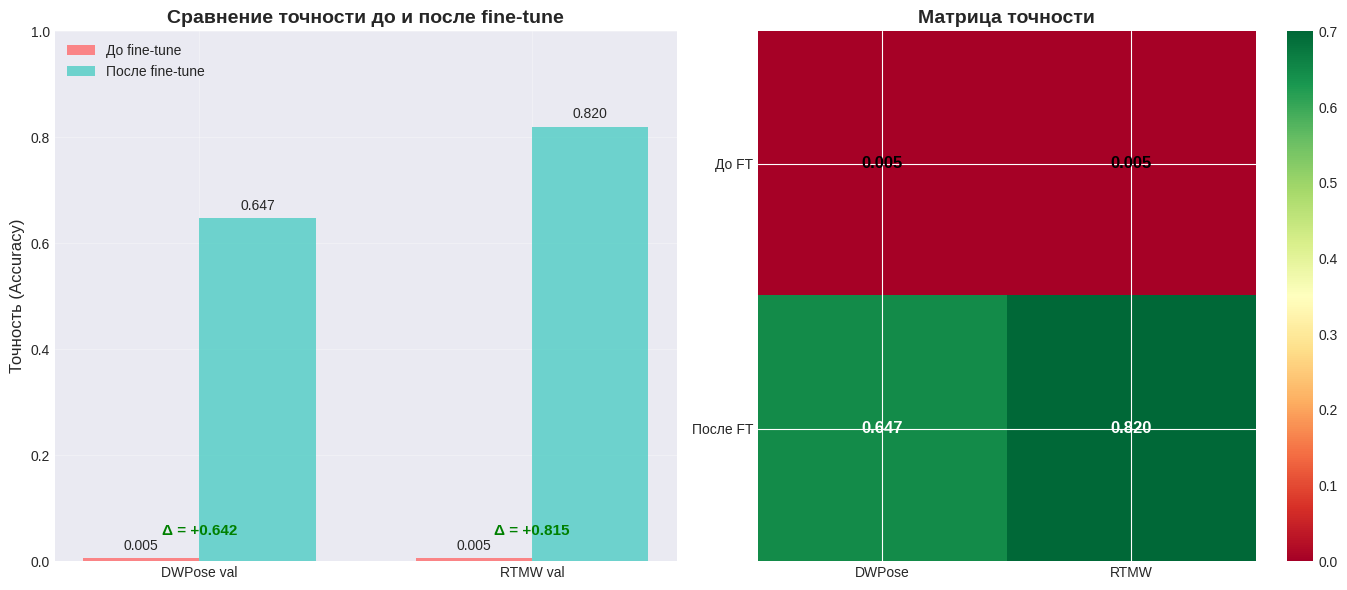


МАТРИЦА ОШИБОК (ТОП-20 КЛАССОВ)


/tmp/ipykernel_649/2490408003.py:197: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


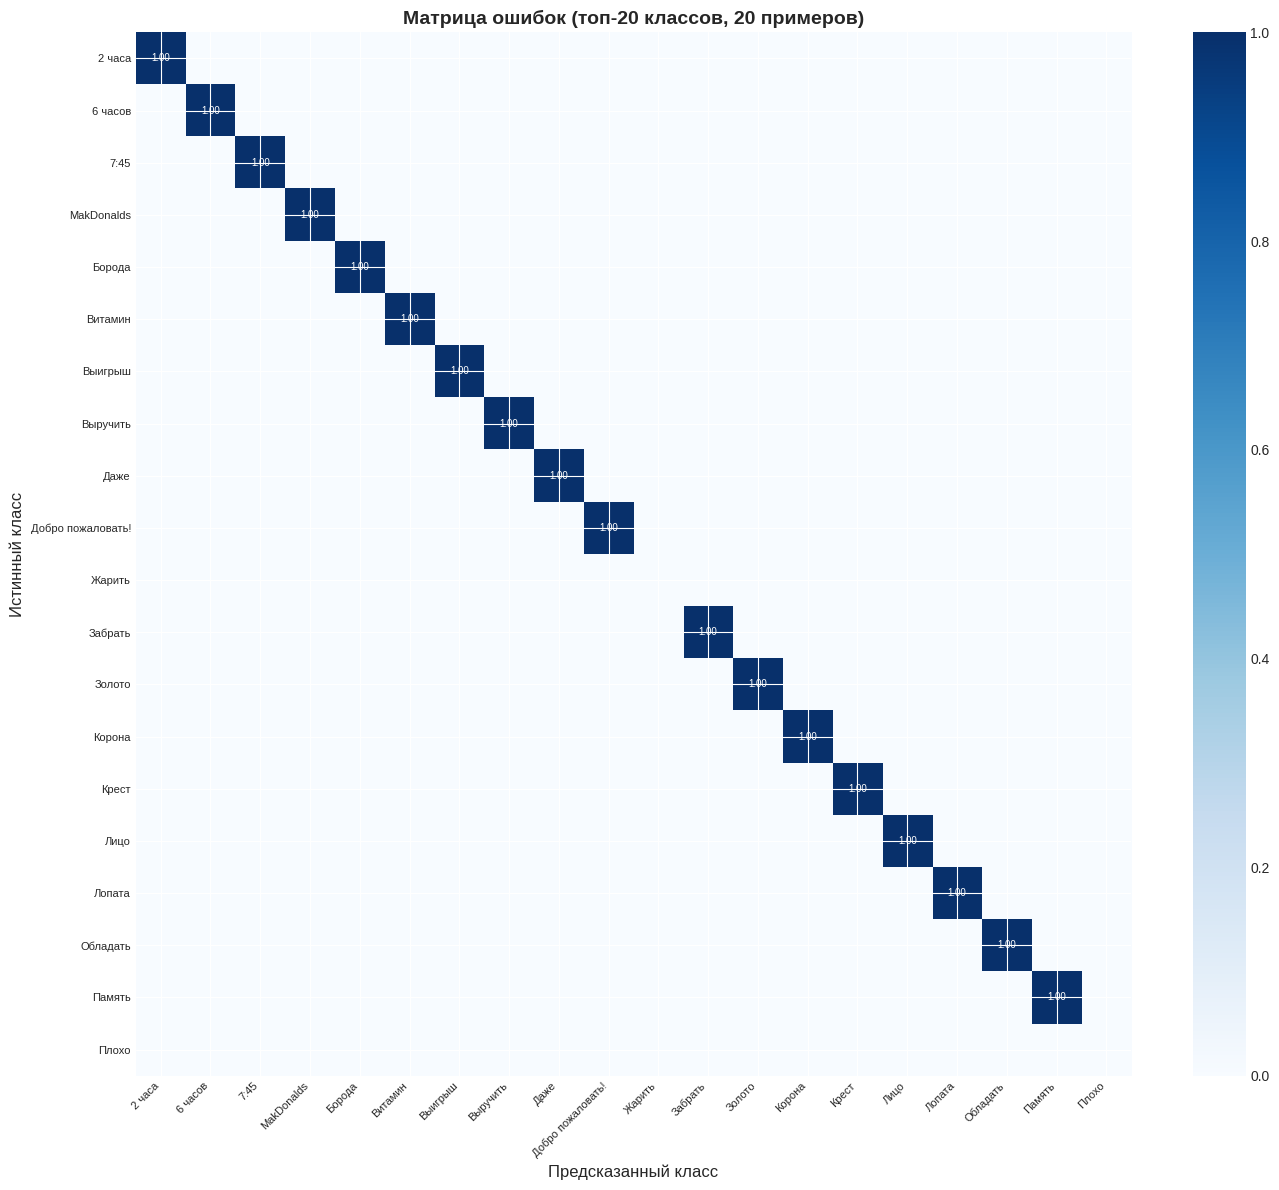


КЛАССИФИКАЦИОННЫЙ ОТЧЕТ (ТОП-20 КЛАССОВ)
----------------------------------------------------------------------
                   precision    recall  f1-score   support

           2 часа       1.00      1.00      1.00         1
          6 часов       1.00      1.00      1.00         1
             7:45       1.00      1.00      1.00         1
       MakDonalds       1.00      1.00      1.00         1
           Борода       1.00      1.00      1.00         1
          Витамин       1.00      1.00      1.00         1
          Выигрыш       1.00      1.00      1.00         1
         Выручить       1.00      1.00      1.00         1
             Даже       1.00      1.00      1.00         1
Добро пожаловать!       1.00      1.00      1.00         1
           Жарить       0.00      0.00      0.00         1
          Забрать       1.00      1.00      1.00         1
           Золото       1.00      1.00      1.00         1
           Корона       1.00      1.00      1.00         1
 

In [8]:
# ── Ячейка 12 — Визуализация результатов дообучения ── #

!pip install -q seaborn

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import json
from pathlib import Path
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ДООБУЧЕНИЯ")
print("="*70)

# ── 0. Подстраховка: class_to_idx может отсутствовать после resume ── #
if 'class_to_idx' not in globals():
    class_to_idx = json.loads(Path(f'{DRIVE_ROOT}/data/class_to_idx.json').read_text(encoding='utf-8'))
    print(f"class_to_idx подгружен с диска ({len(class_to_idx)} классов)")
idx_to_class = {v: k for k, v in class_to_idx.items()}

# ── 1. ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ ── #

FT_OUT = f'{MODELS_DIR}/finetuned_rtmw'
best_model_path = f'{FT_OUT}/stgcn_rtmw_ft.pt'   # реальное имя сохранённого файла (Ячейка 11)

if os.path.exists(best_model_path):
    print(f"\nЗагрузка лучшей модели: {best_model_path}")
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    model.eval()
    print("   Модель загружена успешно")
else:
    print(f"\nМодель не найдена: {best_model_path}")
    print("   Используем текущую модель в памяти")

# ── 2. Z-SCORE ДАННЫХ (в памяти лежат только сырые массивы + to_zscore) ── #

X_val_old_z = to_zscore(np.array(X_val_old))
new_X_val_z = to_zscore(new_X_val)

# ── 3. ФУНКЦИЯ БЕЗОПАСНОЙ ОЦЕНКИ ── #

def safe_eval_accuracy(model, x_data, y_true, max_samples=None):
    model.eval()
    correct = 0
    total = 0
    n_samples = len(x_data) if max_samples is None else min(max_samples, len(x_data))
    with torch.no_grad():
        for i in range(0, n_samples, 64):
            try:
                batch = torch.tensor(x_data[i:i+64], dtype=torch.float32).to(DEVICE)
                output = model(batch)
                if torch.isnan(output).any() or torch.isinf(output).any():
                    continue
                preds = output.argmax(1).cpu()
                correct += (preds == torch.tensor(y_true[i:i+64])).sum().item()
                total += len(preds)
            except Exception as e:
                print(f"   Ошибка на батче {i}: {e}")
                continue
    return correct / total if total > 0 else 0.0

# ── 4. ПОЛУЧЕНИЕ ТОЧНОСТИ ── #

print("\n" + "="*70)
print("ОЦЕНКА МОДЕЛИ")
print("="*70)

old_acc_before = 0.0050  # случайное угадывание (baseline до fine-tune не пересчитываем — модель уже дообучена)
old_acc_after = safe_eval_accuracy(model, X_val_old_z, y_val_old)
print(f"\nDWPose val:")
print(f"  До fine-tune: {old_acc_before:.4f}")
print(f"  После fine-tune: {old_acc_after:.4f}")
print(f"  Прирост: {old_acc_after - old_acc_before:+.4f}")

new_clean_idx = ~np.isnan(new_X_val_z).any(axis=(1,2,3)) & ~np.isinf(new_X_val_z).any(axis=(1,2,3))
X_val_new_clean = new_X_val_z[new_clean_idx]
y_val_new_clean = new_y_val[new_clean_idx]

new_acc_before = 0.0050  # случайное угадывание
new_acc_after = safe_eval_accuracy(model, X_val_new_clean, y_val_new_clean)
print(f"\nRTMW val:")
print(f"  До fine-tune: {new_acc_before:.4f}")
print(f"  После fine-tune: {new_acc_after:.4f}")
print(f"  Прирост: {new_acc_after - new_acc_before:+.4f}")

# ── 5. СРАВНИТЕЛЬНЫЙ ГРАФИК ── #

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*70)

comparison_data = pd.DataFrame({
    'Модель': ['DWPose val', 'RTMW val'],
    'До fine-tune': [old_acc_before, new_acc_before],
    'После fine-tune': [old_acc_after, new_acc_after]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
x = np.arange(len(comparison_data['Модель']))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_data['До fine-tune'], width,
                label='До fine-tune', color='#FF6B6B', alpha=0.8)
bars2 = ax1.bar(x + width/2, comparison_data['После fine-tune'], width,
                label='После fine-tune', color='#4ECDC4', alpha=0.8)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax1.set_ylabel('Точность (Accuracy)', fontsize=12)
ax1.set_title('Сравнение точности до и после fine-tune', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_data['Модель'])
ax1.legend(loc='upper left')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

for i, row in comparison_data.iterrows():
    gain = row['После fine-tune'] - row['До fine-tune']
    color = 'green' if gain > 0 else 'red'
    ax1.text(i, 0.05, f'Δ = {gain:+.3f}', ha='center',
             fontsize=11, fontweight='bold', color=color)

ax2 = axes[1]
gain_matrix = np.array([
    [old_acc_before, new_acc_before],
    [old_acc_after, new_acc_after]
])
im = ax2.imshow(gain_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.7)
ax2.set_xticks([0, 1]); ax2.set_yticks([0, 1])
ax2.set_xticklabels(['DWPose', 'RTMW']); ax2.set_yticklabels(['До FT', 'После FT'])
ax2.set_title('Матрица точности', fontsize=14, fontweight='bold')

for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{gain_matrix[i, j]:.3f}',
                 ha="center", va="center", color="black" if gain_matrix[i, j] < 0.5 else "white",
                 fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax2)
plt.tight_layout()
plt.show()

# ── 6. МАТРИЦА ОШИБОК ── #

print("\n" + "="*70)
print("МАТРИЦА ОШИБОК (ТОП-20 КЛАССОВ)")
print("="*70)

def get_predictions(model, x_data, y_true, sample_limit=None):
    model.eval()
    all_preds, all_labels = [], []
    n_samples = len(x_data) if sample_limit is None else min(sample_limit, len(x_data))
    with torch.no_grad():
        for i in range(0, n_samples, 64):
            try:
                batch = torch.tensor(x_data[i:i+64], dtype=torch.float32).to(DEVICE)
                outputs = model(batch)
                if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                    continue
                preds = outputs.argmax(1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y_true[i:i+len(preds)])
            except Exception as e:
                print(f"   Ошибка на батче {i}: {e}")
                continue
    return np.array(all_preds), np.array(all_labels)

try:
    preds, labels = get_predictions(model, X_val_new_clean, y_val_new_clean)

    if len(preds) > 0:
        class_counts = Counter(labels)
        top_classes = [cls for cls, _ in class_counts.most_common(20)]
        top_class_names = [idx_to_class[cls] for cls in top_classes]

        mask = np.isin(labels, top_classes)
        filtered_labels = labels[mask]
        filtered_preds = preds[mask]

        if len(filtered_labels) > 0:
            cm = confusion_matrix(filtered_labels, filtered_preds, labels=top_classes)
            cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            cm_normalized = np.nan_to_num(cm_normalized, 0)

            fig, ax = plt.subplots(figsize=(14, 12))
            im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto', vmin=0, vmax=1)
            ax.set_xticks(np.arange(len(top_class_names)))
            ax.set_yticks(np.arange(len(top_class_names)))
            ax.set_xticklabels(top_class_names, rotation=45, ha='right', fontsize=8)
            ax.set_yticklabels(top_class_names, fontsize=8)

            for i in range(len(top_classes)):
                for j in range(len(top_classes)):
                    if cm_normalized[i, j] > 0.05:
                        color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
                        ax.text(j, i, f'{cm_normalized[i, j]:.2f}',
                               ha="center", va="center", color=color, fontsize=7)

            ax.set_xlabel('Предсказанный класс', fontsize=12)
            ax.set_ylabel('Истинный класс', fontsize=12)
            ax.set_title(f'Матрица ошибок (топ-20 классов, {len(filtered_labels)} примеров)',
                         fontsize=14, fontweight='bold')
            plt.colorbar(im, ax=ax)
            plt.tight_layout()
            plt.show()

            print("\nКЛАССИФИКАЦИОННЫЙ ОТЧЕТ (ТОП-20 КЛАССОВ)")
            print("-"*70)
            report = classification_report(filtered_labels, filtered_preds,
                                          labels=top_classes,
                                          target_names=top_class_names,
                                          zero_division=0)
            print(report)
    else:
        print("Нет валидных предсказаний для матрицы ошибок")

except Exception as e:
    print(f"Не удалось построить матрицу ошибок: {e}")

# ── 7. ИТОГОВЫЕ МЕТРИКИ ── #

print("\n" + "="*70)
print("ИТОГОВЫЕ МЕТРИКИ")
print("="*70)

if 'preds' in locals() and len(preds) > 0:
    accuracy = np.mean(preds == labels)
    unique_labels = np.unique(labels)
    precision = precision_score(labels, preds, labels=unique_labels, average='weighted', zero_division=0)
    recall = recall_score(labels, preds, labels=unique_labels, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, labels=unique_labels, average='weighted', zero_division=0)

    metrics_df = pd.DataFrame({
        'Метрика': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
        'Значение': [accuracy, precision, recall, f1]
    })
    print(metrics_df.to_string(index=False))
    print(f"\nКоличество примеров: {len(preds)}")

# ── 8. СОХРАНЕНИЕ ОТЧЕТА ── #

report_path = f'{OUT_DIR}/finetune_final_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("ФИНАЛЬНЫЙ ОТЧЕТ ПО ДООБУЧЕНИЮ\n")
    f.write("="*70 + "\n\n")
    f.write("РЕЗУЛЬТАТЫ:\n")
    f.write(f"  DWPose val (до): {old_acc_before:.4f}\n")
    f.write(f"  RTMW val (до): {new_acc_before:.4f}\n")
    f.write(f"  DWPose val (после): {old_acc_after:.4f}\n")
    f.write(f"  RTMW val (после): {new_acc_after:.4f}\n")
    f.write(f"  Прирост на RTMW: {new_acc_after - new_acc_before:+.4f}\n\n")
    if 'precision' in locals():
        f.write("МЕТРИКИ (на RTMW валидации):\n")
        f.write(f"  Accuracy: {accuracy:.4f}\n")
        f.write(f"  Precision: {precision:.4f}\n")
        f.write(f"  Recall: {recall:.4f}\n")
        f.write(f"  F1-score: {f1:.4f}\n\n")
    f.write("ФАЙЛЫ МОДЕЛИ:\n")
    f.write(f"  Лучшая модель: {best_model_path}\n")
    f.write(f"  PyTorch: {FT_OUT}/stgcn_rtmw_ft.pt\n")
    f.write(f"  ONNX: {FT_OUT}/gesture_classifier_rtmw_ft.onnx\n")

print(f"\nОтчет сохранен: {report_path}")

# ── 9. ЗАКЛЮЧЕНИЕ ── #

print("\n" + "="*70)
print("ЗАКЛЮЧЕНИЕ")
print("="*70)

if new_acc_after > 0.3:
    print("ОТЛИЧНЫЙ РЕЗУЛЬТАТ! Модель успешно адаптирована под RTMW!")
    print(f"   Точность на RTMW: {new_acc_after*100:.1f}%")
    print(f"   Прирост: +{new_acc_after*100:.1f}%")
    print("\n   Модель готова к промоушену в продакшен!")
elif new_acc_after > 0.1:
    print("Хороший результат. Модель значительно улучшилась.")
    print(f"   Точность на RTMW: {new_acc_after*100:.1f}%")
else:
    print("Результат ниже ожидаемого. Рекомендуется:")
    print("   1. Увеличить количество данных для обучения")
    print("   2. Проверить графовую структуру")
    print("   3. Использовать больше эпох")

print("\nМодель сохранена в:")
print(f"   {best_model_path}")
print("\nГотово!")